In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
import sys

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'

In [4]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2008-2019_Cases_Dates.txt", "r")
print(f.read())

months: 6, 7, 8, 9, 10, 11, 
years: 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 


In [5]:
r_u = 0.05
near_u = 0.35
smote = 1
scaler = 'minmax'
#years_to_remove = [year for year in range(2012, 2018)]
years_to_remove = []
path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2008_2019.csv'

In [6]:
dataset = read_data(path, exclude_years = years_to_remove)
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,11.79539,45.35783,2008-01-01,veneto,abano terme,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,"19,349",46.86645,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8982.126981,2074.539971,3,170.409233,10.722186,179.966181,0.0,1.063084,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,1,0,0
1,12.04940,45.07048,2008-01-01,veneto,adria,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,"20,233",46.65336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5895.304596,2671.062303,1,142.510779,-0.844161,180.122652,0.0,1.399263,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,1,0,0
2,10.77673,45.55680,2008-01-01,veneto,affi,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,"2,297",46.81410,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5306.025387,738.794180,6,207.641691,201.821006,178.733735,0.0,1.815834,22.0,90.0,20.0,90.0,20.0,90.0,9,9.0,4.0,1.0,1.0,2,0,7,0,0
3,11.96539,45.17531,2008-01-01,veneto,agna,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,"3,400",46.73306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16631.850238,1165.197945,3,121.193871,0.122498,180.188821,0.0,3.769479,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,4,0,0
4,12.05912,46.31399,2008-01-01,veneto,agordo,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,"4,249",47.85821,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15023.566702,684.464446,18,124.001040,1470.386475,152.701532,0.0,2.289867,15.0,92.0,10.0,91.0,10.0,91.0,5,5.0,7.0,1.0,1.0,2,0,14,0,0


In [7]:
dataset = dataset.query('month >= 5 & month <= 11')
dataset.reset_index(inplace=True, drop=True)

In [8]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,11.79539,45.35783,2008-05-01,veneto,abano terme,1,5,18,2008,0.201299,0.979530,0.5,-0.866025,0.845596,-0.533823,"19,349",46.86645,0.359200,0.125381,-0.230218,-0.125381,0.306815,0.056309,-0.261240,-0.056309,0.066939,0.060541,0.020388,0.060541,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8982.126981,2074.539971,3,170.409233,10.722186,179.966181,0.000000,1.063084,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,1,2,0
1,12.04940,45.07048,2008-05-01,veneto,adria,1,5,18,2008,0.201299,0.979530,0.5,-0.866025,0.845596,-0.533823,"20,233",46.65336,0.237252,0.011046,-0.259258,-0.011046,0.245058,0.011140,-0.262177,-0.011140,0.095527,0.094732,0.020674,0.094732,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5895.304596,2671.062303,1,142.510779,-0.844161,180.122652,0.000000,1.399263,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,1,2,0
2,10.77673,45.55680,2008-05-01,veneto,affi,1,5,18,2008,0.201299,0.979530,0.5,-0.866025,0.845596,-0.533823,"2,297",46.81410,0.385675,0.117833,-0.256490,-0.117833,0.399244,0.125362,-0.258663,-0.125362,0.090652,0.053905,0.022167,0.053905,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5306.025387,738.794180,6,207.641691,201.821006,178.733735,0.000000,1.815834,22.0,90.0,20.0,90.0,20.0,90.0,9,9.0,4.0,1.0,1.0,2,0,7,14,0
3,11.96539,45.17531,2008-05-01,veneto,agna,1,5,18,2008,0.201299,0.979530,0.5,-0.866025,0.845596,-0.533823,"3,400",46.73306,0.181247,-0.042393,-0.275554,0.042393,0.248784,0.003760,-0.273113,-0.003760,0.061775,0.053350,0.017033,0.053350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16631.850238,1165.197945,3,121.193871,0.122498,180.188821,0.000000,3.769479,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,4,8,0
4,12.05912,46.31399,2008-05-01,veneto,agordo,1,5,18,2008,0.201299,0.979530,0.5,-0.866025,0.845596,-0.533823,"4,249",47.85821,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15023.566702,684.464446,18,124.001040,1470.386475,152.701532,0.000000,2.289867,15.0,92.0,10.0,91.0,10.0,91.0,5,5.0,7.0,1.0,1.0,2,0,14,28,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95946,12.17878,46.38835,2019-11-16,veneto,zoppe da cadore,16,11,46,2019,-0.101168,-0.994869,-0.5,0.866025,-0.737833,0.674983,265,47.96042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,25000.599626,346.378682,37,238.788886,1403.106042,162.646151,0.000000,2.557130,15.0,94.0,10.0,96.0,10.0,96.0,5,5.0,6.0,4.0,4.0,2,0,8,16,0
95947,11.49430,45.43798,2019-11-16,veneto,zovencedo,16,11,46,2019,-0.101168,-0.994869,-0.5,0.866025,-0.737833,0.674983,796,46.86928,0.571322,0.155106,-0.465696,-0.155106,0.548208,0.162205,-0.425753,-0.162205,0.051183,0.051136,0.085044,0.051136,8.62,11.25,5.99,4.295000,-0.508182,11.538000,3.365556,18.535455,6.696667,19.732000,10.316667,227.983651,343.831703,1972.511516,5077.714670,1967.854592,35,131.888403,267.495086,193.006806,0.000000,1.281697,21.0,73.0,20.0,73.0,20.0,73.0,8,8.0,4.0,4.0,4.0,2,0,1,2,

In [9]:
dataset['lau1'].unique().shape

(571,)

In [10]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2008,7993,1,7994,8.33%
1,2009,7988,6,7994,8.33%
2,2010,7987,7,7994,8.33%
3,2011,7985,9,7994,8.33%
4,2012,7965,32,7997,8.33%
5,2013,7968,27,7995,8.33%
6,2014,7992,2,7994,8.33%
7,2015,7993,1,7994,8.33%
8,2016,7985,9,7994,8.33%
9,2017,7979,16,7995,8.33%


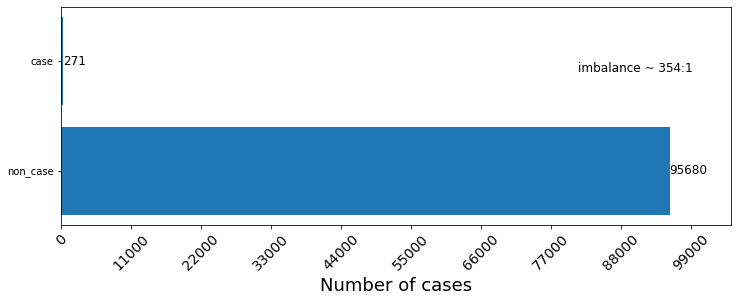

In [11]:
plot_imbalance(dataset)

In [12]:
path2 = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2023-May-2nd.csv'
data_test = read_data(path2, exclude_years = years_to_remove)
data_test.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,11.79539,45.35783,2023-05-16,veneto,abano terme,16,5,20,2023,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"19,349",46.86645,0.305836,0.195181,-0.211233,-0.195181,0.451248,0.214649,-0.369369,-0.214649,0.138496,0.084394,0.116102,0.084394,16.18,22.710000,9.650000,7.577500,0.803333,8.080000,-0.791538,18.345385,6.490000,21.500769,6.950000,70.863885,89.657674,248.764906,8982.126981,2074.539971,3,170.409233,10.722186,179.966181,0.0,1.063084,31,98.0,36,98.0,30,98.0,12,12,1,6,7,2,0,131,0,0
1,12.04940,45.07048,2023-05-16,veneto,adria,16,5,20,2023,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"20,233",46.65336,0.481289,0.218049,-0.444241,-0.218049,0.294163,0.103235,-0.277471,-0.103235,0.090757,0.100037,0.068042,0.100037,14.91,26.136667,3.683333,6.080278,1.536222,8.109212,-1.341825,16.869545,4.825897,21.349744,5.723333,79.000943,86.508775,443.337031,5895.304596,2671.062303,1,142.510779,-0.844161,180.122652,0.0,1.399263,31,99.0,36,99.0,30,99.0,12,12,1,6,7,2,0,203,0,0
2,10.77673,45.55680,2023-05-16,veneto,affi,16,5,20,2023,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"2,297",46.81410,0.215253,0.343317,-0.097417,-0.343317,0.286031,0.303942,-0.179514,-0.303942,0.070778,0.039374,0.082097,0.039374,16.18,21.150000,11.210000,6.294444,0.807143,8.631538,0.720667,17.180000,4.251429,18.359412,6.878889,32.024413,44.276372,102.643676,5306.025387,738.794180,6,207.641691,201.821006,178.733735,0.0,1.815834,31,84.0,30,84.0,30,84.0,10,10,1,6,6,2,0,58,0,0
3,11.96539,45.17531,2023-05-16,veneto,agna,16,5,20,2023,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"3,400",46.73306,0.285199,-0.009342,-0.308480,0.009342,0.363783,0.092128,-0.365535,-0.092128,0.087480,0.080303,0.066134,0.080303,17.71,23.550000,11.870000,4.340000,0.585000,7.752222,-2.034615,15.996667,4.427778,21.254615,5.119231,82.096243,96.321740,402.548818,16631.850238,1165.197945,3,121.193871,0.122498,180.188821,0.0,3.769479,31,99.0,36,99.0,30,99.0,12,12,1,6,7,2,0,90,0,0
4,12.05912,46.31399,2023-05-16,veneto,agordo,16,5,20,2023,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"4,249",47.85821,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,15023.566702,684.464446,18,124.001040,1470.386475,152.701532,0.0,2.289867,15,91.0,10,97.0,10,97.0,5,5,7,1,1,2,0,37,0,0


In [13]:
coefficients = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case']).columns

In [14]:
data_train = dataset
data_test = data_test
    
data_train.reset_index(inplace = True, drop = True)
data_test.reset_index(inplace = True, drop = True)
    
X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['case'])
y_train = data_train['case']
X_test = data_test.select_dtypes(exclude=['object']).drop(columns = ['case'])
y_test = data_test['case']
    
X_train, X_test, y_train, y_test, X_train_df = transform_data(X_train, X_test, y_train, y_test, r_u, near_u, smote, scaler_key=scaler)
    
w0,w1 = calculate_weights(y_train)

model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
    
train, test, coef = train_and_predict(model, X_train_df, data_test, X_train, y_train, X_test, y_test)
    
results_train = results_train.append(train, ignore_index = True)
results_test = results_test.append(test, ignore_index = True)
coefficients.append(coef)
    
print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

Year: 2023 || w0:1, w1:113 || ##


In [15]:
results_test.drop(columns='case').head(40)

,x,y,municipality,day,month,year,probability
0,12.18085,45.26512,codevigo,16,5,2023,0.054617
1,12.24756,45.27153,chioggia,16,5,2023,0.044836
2,12.32478,45.43497,venezia,16,5,2023,0.042443
3,12.30160,45.08601,rosolina,16,5,2023,0.013845
4,12.49633,45.47024,cavallino treporti,16,5,2023,0.009501
5,12.20556,45.34104,campagna lupia,16,5,2023,0.006598
6,12.42147,44.91853,porto tolle,16,5,2023,0.002421
7,11.73897,44.96915,polesella,16,5,2023,0.002410
8,12.64230,45.55959,jesolo,16,5,2023,0.002086
9,12.30118,45.01592,porto viro,16,5,2023,0.001589
